In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!kaggle auth /content/drive/MyDrive/kaggle/access_token
!chmod 600 /content/drive/MyDrive/kaggle/access_token

!mkdir -p ~/.kaggle # creating .kaggle folder where the key should be placed
!cp /content/drive/MyDrive/kaggle/access_token ~/.kaggle/ # move the key to the folder

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p .
!unzip -q /content/chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 155MB/s]



In [5]:
!git clone https://github.com/EdoardoGrassi/xai-binary-classification

Cloning into 'xai-binary-classification'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 28 (delta 7), reused 21 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 206.90 KiB | 5.91 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [6]:
# fix import paths into the repository
import sys
sys.path.insert(0,'./xai-binary-classification')

In [17]:
import os
from pathlib import Path

import numpy as np
import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from tqdm import tqdm

from convnet import ConvNet
from datasets import ChestXRay
# from scatnet import ScatNet

RNG = tc.Generator().manual_seed(0)

transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToImage(),
    # tvs.CenterCrop(128),
    tvs.Resize((128, 128)),
    tvs.RandomHorizontalFlip(), # bit of data augmentation
    tvs.ConvertImageDtype(tc.float32),
])

ROOT = Path("/content/chest_xray")

dataset = tc.utils.data.ConcatDataset([
    ImageFolder(Path(ROOT, "train"), transform=transforms),
    ImageFolder(Path(ROOT, "val"), transform=transforms),
    # ImageFolder(Path(ROOT, "test"), transform=transforms),
])

BATCH_SIZE: int = 200
WORKERS: int = 2

train_dataset, valid_dataset = tc.utils.data.random_split(dataset, [0.8, 0.2], generator=RNG)

device = tc.device("cuda")

SHAPE = (1, 128, 128)
model = ConvNet(shape=SHAPE).to(device)
model.compile()

In [31]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import SubsetRandomSampler

EPOCHS: int = 5

criterion = tc.nn.CrossEntropyLoss().to(device)
optimizer = tc.optim.Adam(model.parameters())

acc_train = []; f1_train = []; loss_train = []
acc_valid = []; f1_valid = []; loss_valid = []

# cross validation
folds = StratifiedKFold(n_splits=5)
# dummy shape to generate the splits
X = np.zeros(len(train_dataset))
y = np.concat([x.targets for x in dataset.datasets])[train_dataset.indices]
for i, (train_index, valid_index) in enumerate(folds.split(X, y)):
    train_loader = DataLoader(
        train_dataset,
        sampler=SubsetRandomSampler(train_index, generator=RNG),
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )
    valid_loader = DataLoader(
        train_dataset,
        sampler=SubsetRandomSampler(valid_index, generator=RNG),
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )

    # for epoch in tqdm(range(EPOCHS), "Training"):
    for epoch in range(EPOCHS):
        print("Epoch:", epoch)

        running_loss = []
        running_acc = []
        running_f1 = []
        model.train()
        for images, labels in tqdm(train_loader, "Train on batches"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy, and F1-score
            predicted = tc.argmax(outputs, dim=-1)
            running_loss.append(loss.item())
            running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
            running_f1.append(f1_score(labels.cpu(), predicted.cpu(), average="weighted"))
            # print("Batch accuracy score", accuracy_score(labels.cpu(), predicted.cpu()))

        loss_train.append(np.mean(running_loss))
        acc_train.append(np.mean(running_acc))
        f1_train.append(np.mean(running_f1))

        print(
            f"  Train - Loss: {loss_train[epoch]:.4f}, Acc: {acc_train[epoch]:.4f}, F1: {f1_train[epoch]:.4f}"
        )

        # Validation phase
        model.eval()
        running_loss = []
        running_acc = []
        running_f1 = []
        with tc.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, predicted = tc.max(outputs, 1)
                running_loss.append(loss.item())
                running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
                running_f1.append(
                    f1_score(labels.cpu(), predicted.cpu(), average="weighted")
                )

            loss_valid.append(np.mean(running_loss))
            acc_valid.append(np.mean(running_acc))
            f1_valid.append(np.mean(running_f1))

            print(
                f"  Valid - Loss: {loss_valid[epoch]:.4f}, Acc: {acc_valid[epoch]:.4f}, F1: {f1_valid[epoch]:.4f}"
            )

Epoch: 0


Train on batches: 100%|██████████| 17/17 [00:44<00:00,  2.64s/it]

  Train - Loss: 1.6406, Acc: 0.8191, F1: 0.7826


  Valid - Loss: 1.0675, Acc: 0.8622, F1: 0.8417
Epoch: 1


Train on batches: 100%|██████████| 17/17 [00:43<00:00,  2.57s/it]

...

  Train - Loss: 0.0916, Acc: 0.9685, F1: 0.9684


  Valid - Loss: 0.1028, Acc: 0.9667, F1: 0.9661
Epoch: 4


Train on batches: 100%|██████████| 17/17 [00:45<00:00,  2.65s/it]

  Train - Loss: 0.0955, Acc: 0.9637, F1: 0.9635


  Valid - Loss: 0.0881, Acc: 0.9665, F1: 0.9662


TypeError: Invalid shape (37, 102, 128) for image data

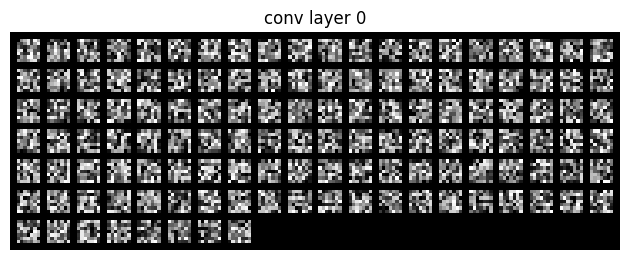

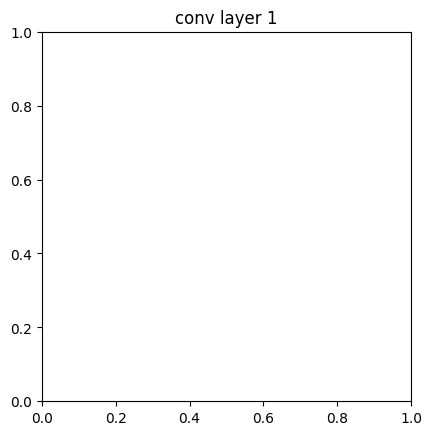

In [15]:
# visualize filters
import matplotlib.pyplot as plt
import torchvision

for i, layer in enumerate([model.conv0.weight, model.conv1.weight]):
    fig, ax = plt.subplots()
    ax.set_title(f"conv layer {i}")
    image = torchvision.utils.make_grid(layer.cpu(), nrow=20, normalize=True, scale_each=True)
    # bring channel axis to the last place
    ax.imshow(image.numpy().transpose((1, 2, 0)))
    ax.axis("off")
    fig.tight_layout()

In [9]:
# export the trained model

save_folder = Path("weights")
save_folder.mkdir(exist_ok=True)
tc.save(model.state_dict(), Path(save_folder, f"{model.name}.pt"))

In [10]:
# test the model

test_dataset = ImageFolder(Path(ROOT, "train"), transform=transforms)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

def test_model(model: tc.nn.Module, images_loader: DataLoader):

    model.eval()
    all_preds = []
    all_labels = []

    with tc.no_grad():
        for images, labels in images_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = tc.argmax(outputs, dim=-1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f'Test Accuracy: {accuracy:.4f}, Test F1-score: {f1:.4f}')

test_model(model, test_loader)

Test Accuracy: 0.9348, Test F1-score: 0.9316
